In [1]:
# numpy는 배열 계산을 쉽게 하기 위해 사용합니다
import numpy as np
from math import e

In [2]:
# ============================================================
#  1. 입력값 X와 정답 y 준비
# ============================================================

# X: 입력값입니다. 여기서는 사람의 키(cm)를 사용합니다.
X = np.array([160, 170, 180, 190])

X
# y: 정답값입니다. 여기서는 0은 농구선수 아님, 1은 농구선수 입니다.
y = np.array([0, 0, 1, 1])

y

print("입력값 X:", X)
print("입력값 y:", y)

입력값 X: [160 170 180 190]
입력값 y: [0 0 1 1]


## 1장 . 입력값 X를 학습용 입력 X_norm 으로 준비하기

In [16]:
# ============================================================
#  2. 입력값 정규화
# ============================================================

# 평균과 표준편차를 계산합니다.
# 평균은 데이터의 중심, 표준편차는 데이터가 평균에서 얼마나 퍼져 있는지를 나타냅니다.
X_mean = np.mean(X)
X_std = np.std(X)

# 정규화 공식: (원본값 - 평균) / 표준편차
# 입력값의 범위를 비슷하게 맞추면 학습이 더 안정적으로 진행 됩니다.
X_norm = (X - X_mean) / X_std

print("입력값 평균 X_mean:", X_mean)
print("입력값 표준편차 X_std:", X_std)
print("정규화된 입력값 X_norm:", X_norm)

입력값 평균 X_mean: 175.0
입력값 표준편차 X_std: 11.180339887498949
정규화된 입력값 X_norm: [-1.34164079 -0.4472136   0.4472136   1.34164079]


## 2장. H(x)와 z를 구분하기

In [4]:
# ============================================================
#  3. 가중치 a와 b 초기값 설정
# ============================================================

# a 는 가중치 (weight), b는 편향(bias) 입니다.
# 여기서 a 는 원래 키(cm)가 아니라 정규화 된 입력값 X_norm 에곱해지는 값입니다.

a = 0.1
b = 0.0

In [5]:
# ============================================================
#   4. 시그모이드 함수 정의
# ============================================================

# 시그모이드 함수는 선형 계산값 H(x)를  0~1 사이의 확률 값 z 로 변환합니다.
def sigmoid(H):
    return 1 / (1 + e** (-H))

In [17]:
# ============================================================
#   5. 학습전 예측 확인
# ============================================================

# H(x) = ax + b
# H(x)는 퍼셉트론의 선형 계산값입니다.
H = a * X_norm + b

# z = sigmoid(H)
# z 는 농구선수일 예측 확률입니다.
z = sigmoid(H)

print("\n 학습 전 선형 계산 값 H(x):", H)
print("학습 전 시그모이드 예측 확률 z:", z)


 학습 전 선형 계산 값 H(x): [-9.08718379 -3.02906126  3.02906126  9.08718379]
학습 전 시그모이드 예측 확률 z: [1.13093359e-04 4.61301158e-02 9.53869884e-01 9.99886907e-01]


## 3장. z와 y를 비교해 Costs 계산하기

In [18]:
# ============================================================
#   6. 학습 전 비용(Cost) 계산
# ============================================================

# Binary Cross Entropy 비용 함수 입니다.
# 실제값 y 가 1이면 z가 1에 가까울수록 비용이 작아지고,
# 실제값 y 가 0이면 z가 0에 가까울수록 비용이 작아집니다.
#
# Cost = - {y * log(z) + (1 - y) * log(1 - z)}
# log(0)을 방지하기 위해 z 가 정확히 0또는 1이 되지 않도록 제한합니다.
epsilon = 1e-7
z_safe = np.clip(z, epsilon, 1 - epsilon)

costs = - (y * np.log(z_safe) + (1 - y) * np.log(1 - z_safe))
mean_cost = np.mean(costs)

print("학습 전 각 샘플의 비용 (Cost):", costs)
print("학습 전 평균 비용 (mean_Cost):", mean_cost)

학습 전 각 샘플의 비용 (Cost): [0.0001131  0.04722801 0.04722801 0.0001131 ]
학습 전 평균 비용 (mean_Cost): 0.02367055315324141


## 4장. Cost에서  a,b 까지 거꾸로 따라가기
## 5장. Gradient Denscent로 a,b 수정하기

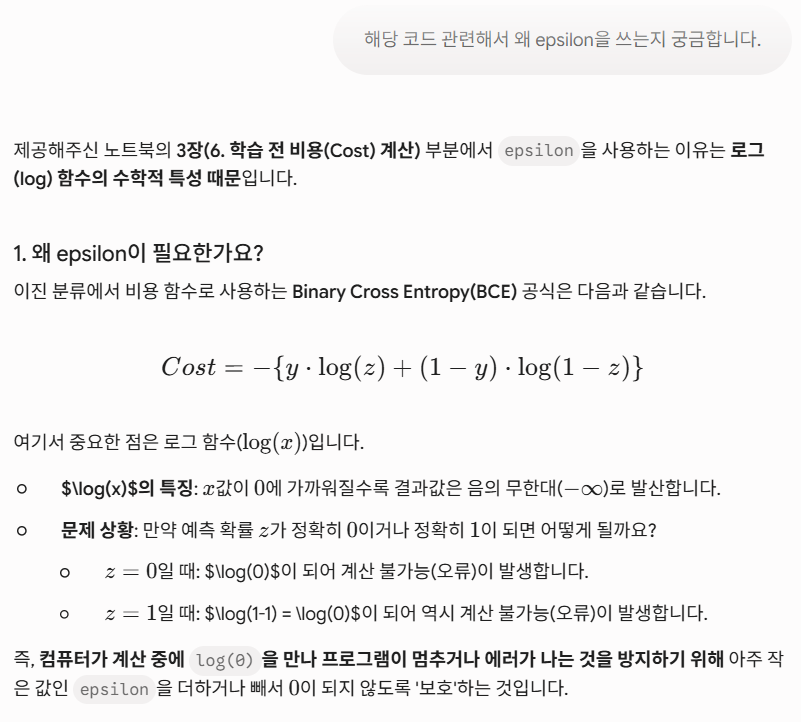

In [12]:
# ============================================================
#   7. 학습 설정
# ============================================================

# learning_rate는 한번에 얼마나 크게 이동할지를 정하는 학습률입니다.
learning_rate = 0.1

# epochs 는 전체 데이터를 몇 번 반복해서 학습할지 정하는 값입니다.
epochs = 1000

In [19]:
# ============================================================
#   8. 경사 하강법으로 학습
# ============================================================

for epoch in range(epochs):
    
    # 1단계: 선형 계산 H(x) = ax + b
    H = a * X_norm + b
    
    # 2단계: 시그모이드 함수를 적용해 예측 확률 z 계산
    z = sigmoid(H)
    
    # 3단계: log(0) 방지
    z_safe = np.clip(z, epsilon, 1 - epsilon)
    
    # 4단계: 기울기 계산
    # BCE 와 sigmoid를 함께 미분하면 z - y 가 등장합니다.
    # z 는 예측 확률이고 y는 실제 정답입니다.
    grad_a = np.mean((z-y)* X_norm)
    grad_b = np.mean(z-y)
    
    # 5단계: 경사 하강법으로 a, b 업데이트
    # 세로운 값 = 기존 값 - 학습률 * 기울기
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    
    # 6단계: 현재 비용(Cost) 계산
    costs = - (y * np.log(z_safe) + (1 - y) * np.log(1 - z_safe))
    mean_cost = np.mean(costs)
    
    # 100번 마다 한 번 씩 학습 상태를 출력합니다.
    if epoch % 100 == 0 or epoch == epochs -1 :
        print(f"Epoch {epoch}, 평균비용(cost): {mean_cost:.6f}, a: {a}, b: {b}")

Epoch 0, 평균비용(cost): 0.023671, a: 6.774225983386814, b: 8.361367154208223e-17
Epoch 100, 평균비용(cost): 0.022637, a: 6.875840294509361, b: 8.812395257962191e-17
Epoch 200, 평균비용(cost): 0.021689, a: 6.973165419866782, b: 1.1379786002407868e-16
Epoch 300, 평균비용(cost): 0.020817, a: 7.066546374806076, b: 1.1605300054284858e-16
Epoch 400, 평균비용(cost): 0.020011, a: 7.156288143004672, b: 1.4883927423881012e-16
Epoch 500, 평균비용(cost): 0.019264, a: 7.242661661355, b: 1.963706974805745e-16
Epoch 600, 평균비용(cost): 0.018571, a: 7.325908720739328, b: 1.7243151351209449e-16
Epoch 700, 평균비용(cost): 0.017925, a: 7.406246011551118, b: 1.4901274658640764e-16
Epoch 800, 평균비용(cost): 0.017322, a: 7.483868488013432, b: 1.7746221159242726e-16
Epoch 900, 평균비용(cost): 0.016758, a: 7.558952185135551, b: 1.5629858518551014e-16
Epoch 999, 평균비용(cost): 0.016234, a: 7.630940838575526, b: 1.6393136847980807e-16


## 6장. 학습된a,b 로 새로운 키 예측하기

In [14]:
# ============================================================
#   9. 학습 완료 후 최종 가중치와 편향 확인
# ============================================================

# 학습된 a와 b는 정규화된 입력값 X_norm을 기준으로 학습된 값입니다.
print(f"\n 학습완료 후의 최적값: a = {a}, b = {b}")


 학습완료 후의 최적값: a = 6.77318689610651, b = 8.135853102331239e-17


In [15]:
# ============================================================
#   10. 새로운 입력값 예측
# ============================================================

# 키가 185cm 인 사람이 농구선수인지 예측합니다.
input_height = 185

# 새로운 입력값도 학습 데이터와 같은 방식으로 정규화 해야 합니다.
input_norm = (input_height - X_mean) / X_std

# H(x)를  계산한 뒤 sigmoid 를 적용해 확률로 변환합니다.
H_input = a * input_norm + b
probability = sigmoid(H_input)

print(f"\n 키가 {input_height}cm 인 사람의 농구선수 확률: {probability:.4f}")

# 이진 분류에서는 보통 확률이 0.5 dltkddlaus 1, 0.5 미만이면 0 으로 판단합니다.
if probability >= 0.5:
    print("판별 결과: 농구선수입니다.")
else:
    print("판별 결과: 농구선수가 아닙니다.")


 키가 185cm 인 사람의 농구선수 확률: 0.9977
판별 결과: 농구선수입니다.
